# Cognitive Load Detection with AI

This notebook explores how machine learning can classify cognitive load levels using simulated EEG-like brain signal data.

The goal of this experiment is to explore the intersection of artificial intelligence, neuroscience, and human cognition.

We simulate neural signal features, visualize signal patterns, and train a machine learning model to detect cognitive load levels.

## Model Training

We train a Random Forest classifier to predict cognitive load levels based on the simulated signal features.

The dataset is split into training and testing sets to evaluate model performance.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [6]:
np.random.seed(42)

samples_per_class = 100
features = 10

low_load = np.random.normal(loc=0.2, scale=0.1, size=(samples_per_class, features))
medium_load = np.random.normal(loc=0.5, scale=0.1, size=(samples_per_class, features))
high_load = np.random.normal(loc=0.8, scale=0.1, size=(samples_per_class, features))

X = np.vstack([low_load, medium_load, high_load])

y = np.array([0]*samples_per_class + [1]*samples_per_class + [2]*samples_per_class)

In [7]:
feature_names = [f"signal_{i+1}" for i in range(features)]

df = pd.DataFrame(X, columns=feature_names)

df["cognitive_load"] = y

df.head()

,signal_1,signal_2,signal_3,signal_4,signal_5,signal_6,signal_7,signal_8,signal_9,signal_10,cognitive_load
0,0.249671,0.186174,0.264769,0.352303,0.176585,0.176586,0.357921,0.276743,0.153053,0.254256,0
1,0.153658,0.153427,0.224196,0.008672,0.027508,0.143771,0.098717,0.231425,0.109198,0.058770,0
2,0.346565,0.177422,0.206753,0.057525,0.145562,0.211092,0.084901,0.237570,0.139936,0.170831,0
3,0.139829,0.385228,0.198650,0.094229,0.282254,0.077916,0.220886,0.004033,0.067181,0.219686,0
4,0.273847,0.217137,0.188435,0.169890,0.052148,0.128016,0.153936,0.305712,0.234362,0.023696,0


## Signal Visualization

Before training the model, we explore the structure of the simulated EEG-like signals.

These visualizations illustrate how different cognitive load levels may produce distinct signal patterns across features.

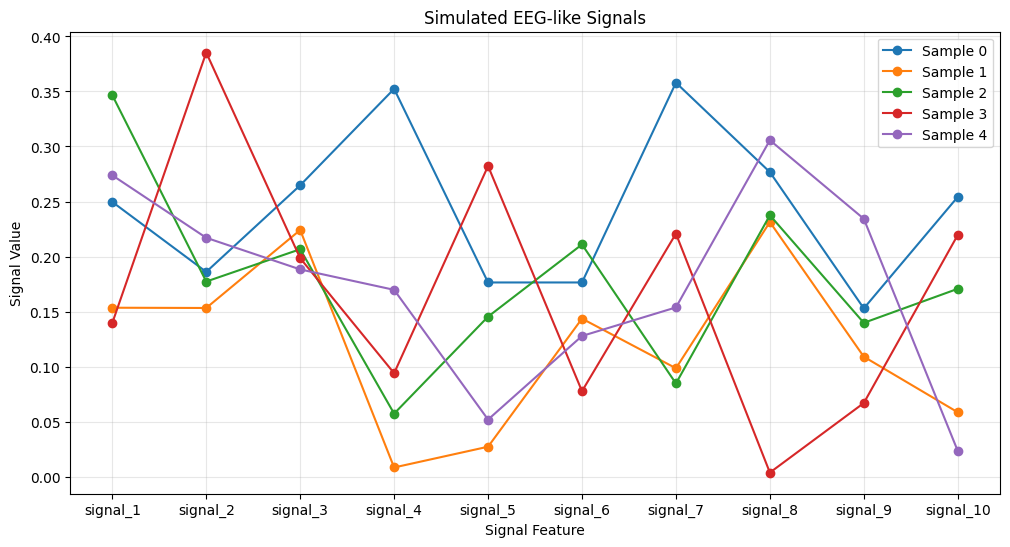

In [8]:
plt.figure(figsize=(12,6))

for i in range(5):
    plt.plot(df.loc[i, feature_names], marker="o", label=f"Sample {i}")

plt.title("Simulated EEG-like Signals")
plt.xlabel("Signal Feature")
plt.ylabel("Signal Value")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("eeg_signals.png")
plt.show()

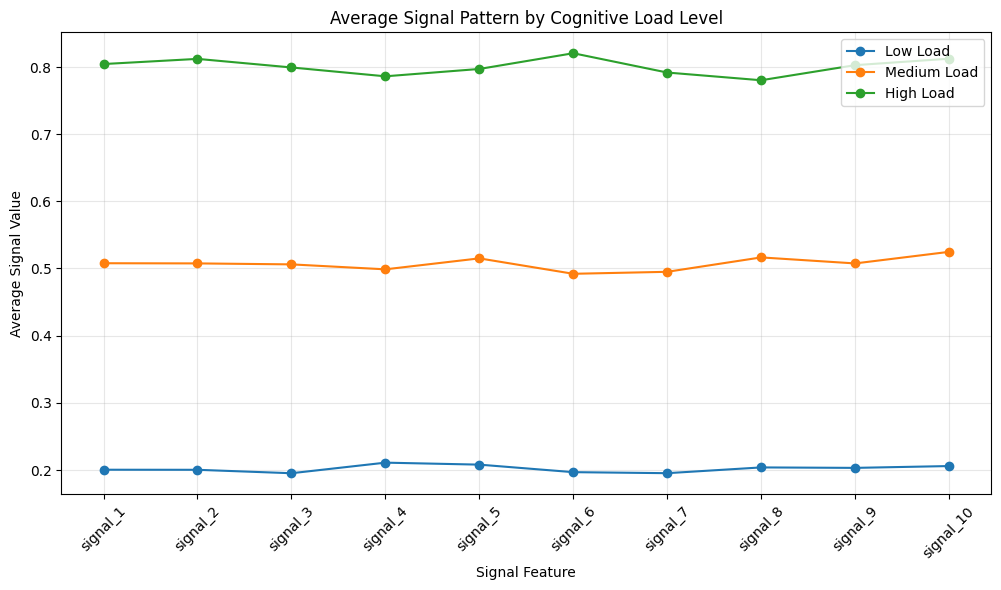

In [9]:
plt.figure(figsize=(12,6))

for label, name in zip([0,1,2], ["Low Load","Medium Load","High Load"]):

    class_mean = df[df["cognitive_load"] == label][feature_names].mean()

    plt.plot(feature_names, class_mean, marker="o", label=name)

plt.title("Average Signal Pattern by Cognitive Load Level")
plt.xlabel("Signal Feature")
plt.ylabel("Average Signal Value")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("average_signal_patterns.png")

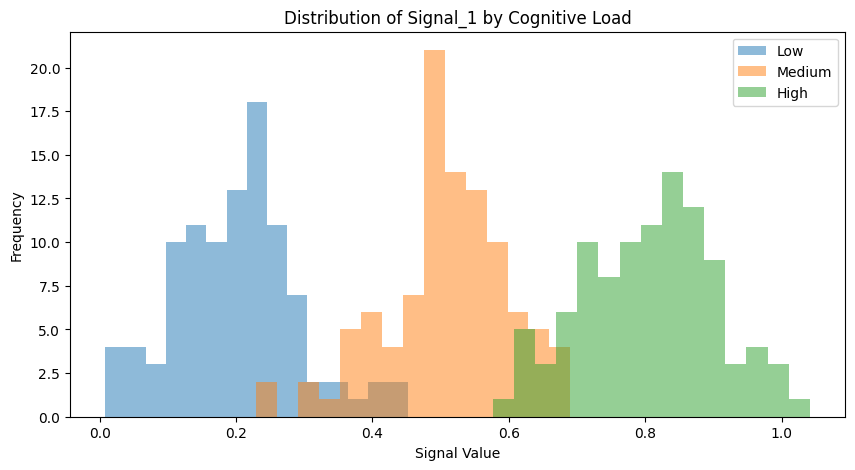

In [10]:
plt.figure(figsize=(10,5))

for label, name in zip([0,1,2], ["Low","Medium","High"]):

    plt.hist(
        df[df["cognitive_load"] == label]["signal_1"],
        bins=15,
        alpha=0.5,
        label=name
    )

plt.title("Distribution of Signal_1 by Cognitive Load")
plt.xlabel("Signal Value")
plt.ylabel("Frequency")

plt.legend()

plt.savefig("signal_distribution.png")

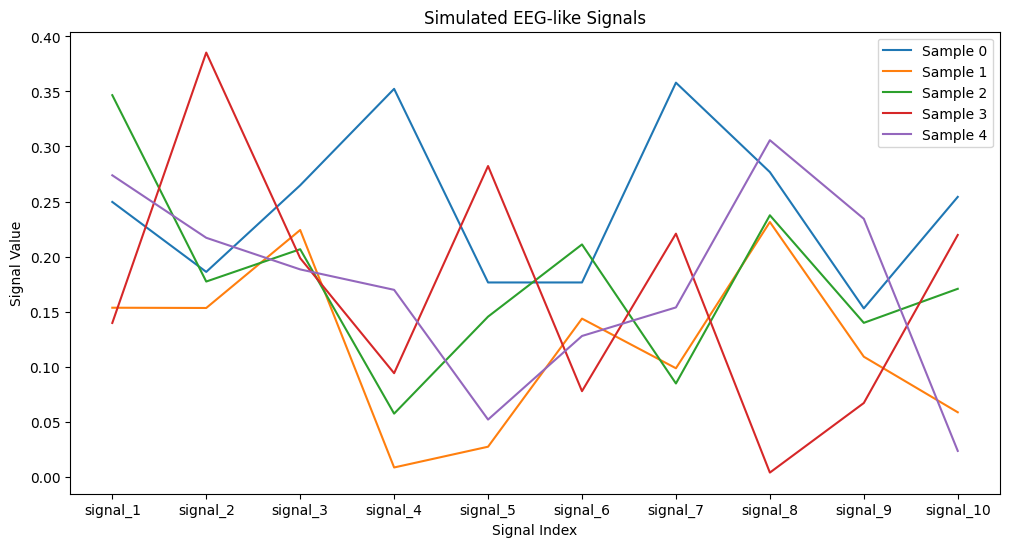

In [11]:
plt.figure(figsize=(12,6))

for i in range(5):
    plt.plot(df.loc[i, feature_names], label=f"Sample {i}")

plt.title("Simulated EEG-like Signals")
plt.xlabel("Signal Index")
plt.ylabel("Signal Value")
plt.legend()
plt.show()

In [12]:
import numpy as np
import pandas as pd

def extract_frequency_features(df, feature_cols):

    fft_mean = []
    fft_max = []
    fft_std = []

    for _, row in df[feature_cols].iterrows():

        signal = row.values
        fft_vals = np.abs(np.fft.fft(signal))

        fft_mean.append(np.mean(fft_vals))
        fft_max.append(np.max(fft_vals))
        fft_std.append(np.std(fft_vals))

    freq_df = pd.DataFrame({
        "fft_mean": fft_mean,
        "fft_max": fft_max,
        "fft_std": fft_std
    })

    return freq_df

In [13]:
freq_features = extract_frequency_features(df, feature_names)

freq_features.head()

,fft_mean,fft_max,fft_std
0,0.397870,2.448061,0.698603
1,0.308266,1.209342,0.320265
2,0.390220,1.778156,0.472790
3,0.459967,1.689893,0.438229
4,0.415128,1.747178,0.453795


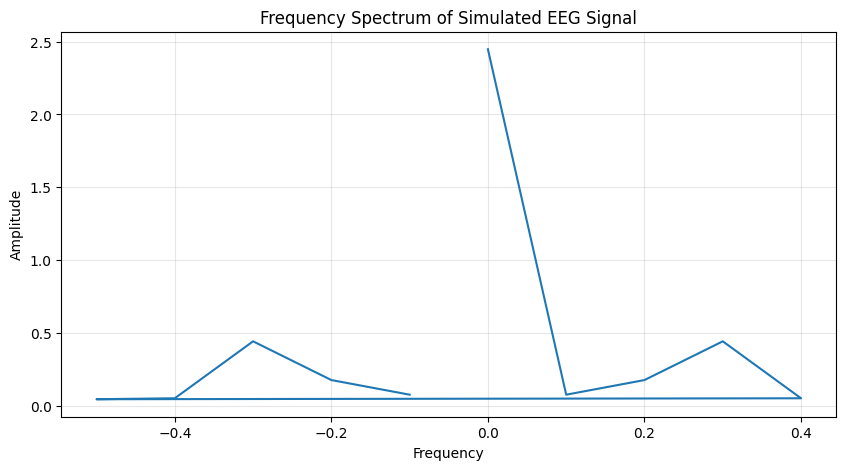

In [17]:
# FFT Spectrum Visualization (EEG-style frequency analysis)

sample_signal = df.loc[0, feature_names].values

fft_vals = np.abs(np.fft.fft(sample_signal))
freqs = np.fft.fftfreq(len(sample_signal))

plt.figure(figsize=(10,5))

plt.plot(freqs, fft_vals)
plt.title("Frequency Spectrum of Simulated EEG Signal")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")

plt.grid(True, alpha=0.3)

plt.savefig("fft_spectrum.png")

plt.show()

In [14]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [15]:
df_extended = pd.concat([df, freq_features], axis=1)

df_extended.head()

,signal_1,signal_2,signal_3,signal_4,signal_5,signal_6,signal_7,signal_8,signal_9,signal_10,cognitive_load,fft_mean,fft_max,fft_std
0,0.249671,0.186174,0.264769,0.352303,0.176585,0.176586,0.357921,0.276743,0.153053,0.254256,0,0.397870,2.448061,0.698603
1,0.153658,0.153427,0.224196,0.008672,0.027508,0.143771,0.098717,0.231425,0.109198,0.058770,0,0.308266,1.209342,0.320265
2,0.346565,0.177422,0.206753,0.057525,0.145562,0.211092,0.084901,0.237570,0.139936,0.170831,0,0.390220,1.778156,0.472790
3,0.139829,0.385228,0.198650,0.094229,0.282254,0.077916,0.220886,0.004033,0.067181,0.219686,0,0.459967,1.689893,0.438229
4,0.273847,0.217137,0.188435,0.169890,0.052148,0.128016,0.153936,0.305712,0.234362,0.023696,0,0.415128,1.747178,0.453795


In [16]:
feature_cols = feature_names + ["fft_mean", "fft_max", "fft_std"]

X = df_extended[feature_cols]
y = df_extended["cognitive_load"]

In [6]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



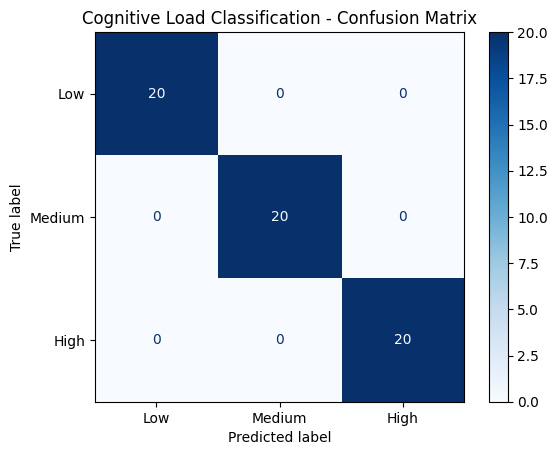

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=["Low", "Medium", "High"],
    cmap="Blues"
)

plt.title("Cognitive Load Classification - Confusion Matrix")
plt.savefig("confusion_matrix.png")

plt.show()

## Conclusion

This experiment demonstrates a basic workflow for detecting cognitive load levels using simulated EEG-like signals.

Although the dataset is synthetic, the pipeline reflects real-world steps used in neurotechnology and AI research:

- signal representation as structured features
- exploratory visualization of neural signals
- machine learning classification
- evaluation of model performance

Future experiments may include:

- real EEG datasets
- feature extraction from frequency domains
- deep learning models for neural signals
- applications to brain-computer interfaces
